1. Imports and load key

In [20]:
import requests
import zipfile
import io
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("Libraries imported successfully.")

Libraries imported successfully.


2. Download USDA PSD bulk CSV

In [21]:
url = "https://apps.fas.usda.gov/psdonline/downloads/psd_oilseeds_csv.zip"

print("Downloading USDA pSD oilseeds CSV...")
response = requests.get(url, timeout=60)
print(f"status code: {response.status_code}")
print(f"File size: {len(response.content) / 1_000_000:.1f} MB")

assert response.status_code == 200, \
    f"Failed to download file: {response.status_code}"
print("Download successful, unzipping...")


status code: 200
File size: 3.8 MB
Download successful, unzipping...


3. Load CSV from zip (no need to save to disk)

In [ ]:
# Unzip in memory using io.BytesIO — cleaner than saving a temp file

z = zipfile.ZipFile(io.BytesIO(response.content))
print("Files in zip:", z.namelist())

df_raw = pd.read_csv(z.open("psd_oilseeds.csv"))

print(f"\nShape: {df_raw.shape}")
print(f"Columns: {df_raw.columns.to_list()}")
print("\nSample data:")
print(df_raw.head(1).to_string())

Files in zip: ['psd_oilseeds.csv']

Shape: (801669, 12)
Columns: ['Commodity_Code', 'Commodity_Description', 'Country_Code', 'Country_Name', 'Market_Year', 'Calendar_Year', 'Month', 'Attribute_ID', 'Attribute_Description', 'Unit_ID', 'Unit_Description', 'Value']

Sample data:
   Commodity_Code Commodity_Description Country_Code Country_Name  Market_Year  Calendar_Year  Month  Attribute_ID Attribute_Description  Unit_ID Unit_Description  Value
0          813700           Meal, Copra           AS    Australia         1964           2006      6            20      Beginning Stocks        8        (1000 MT)    0.0


4. Verify commodity and country code (palm oil and indonesia)

In [23]:
print("Palm oil comoodity codes in dataset:")
print(df_raw[df_raw["Commodity_Description"].str.contains("Palm", case=False)][
    ["Commodity_Code", "Commodity_Description"]
].drop_duplicates().to_string())

print("\nIndonesia country code:")
print(df_raw[df_raw["Country_Name"].str.contains("Indonesia", case=False)][
    ["Country_Code", "Country_Name"]
].drop_duplicates().to_string())


Palm oil comoodity codes in dataset:
        Commodity_Code Commodity_Description
90622           813800     Meal, Palm Kernel
346788         4243000             Oil, Palm
400764         4244000      Oil, Palm Kernel
639270         2232000  Oilseed, Palm Kernel

Indonesia country code:
     Country_Code Country_Name
5838           ID    Indonesia


Confirmed:\
   Commodity: 4243000 = Oil, Palm (not Palm Kernel — PKO is for cosmetics)\
   Country:   ID      = Indonesia

5. Filter to Indonesia palm oil

In [24]:
df_indo = df_raw[
    (df_raw["Commodity_Code"] == 4243000) &
    (df_raw["Country_Code"] == "ID")
].copy()

print(f"Indonesia palm oil rows: {df_indo.shape[0]}")
print("\nAll available attributes:")
print(df_indo[["Attribute_ID", "Attribute_Description", "Unit_Description"]]
      .drop_duplicates()
      .sort_values("Attribute_ID")
      .to_string())

Indonesia palm oil rows: 819

All available attributes:
        Attribute_ID  Attribute_Description Unit_Description
368485             4         Area Harvested        (1000 HA)
368486            20       Beginning Stocks        (1000 MT)
368494            28             Production        (1000 MT)
368492            57                Imports        (1000 MT)
368496            86           Total Supply        (1000 MT)
368489            88                Exports        (1000 MT)
368487           125   Domestic Consumption        (1000 MT)
368493           140  Industrial Dom. Cons.        (1000 MT)
368491           149    Food Use Dom. Cons.        (1000 MT)
368490           161  Feed Waste Dom. Cons.        (1000 MT)
368488           176          Ending Stocks        (1000 MT)
368495           178     Total Distribution        (1000 MT)
368497           184                  Yield          (MT/HA)


Attributes explained:
   - 4   = Area Harvested       — plantation size, not needed
   - 20  = Beginning Stocks     — carry-in from previous year
   - 28  = Production           — total output, 1000 MT
   - 57  = Imports              — tiny for Indonesia, not needed
   - 86  = Total Supply         — derived total, not needed
   - 88  = Exports              — volume reaching global market ✓
   - 125 = Domestic Consumption — total domestic use (food + biodiesel + other)
   - 140 = Industrial Dom. Cons — THIS IS BIODIESEL ✓
   - 149 = Food Use Dom. Cons.  — cooking oil, stable, not policy-driven
   - 161 = Feed Waste Dom. Cons — tiny, not relevant
   - 176 = Ending Stocks        — surplus/deficit signal ✓
   - 178 = Total Distribution   — derived total, not needed
   - 184 = Yield                — MT/HA, plantation metric, not needed

6. Extract the four attributes needed and pivot to side format

In [ ]:
# We select:
#   Production              — supply starting point
#   Industrial Dom. Cons.   — biodiesel absorption (the B-mandate number)
#   Exports                 — volume competing with Malaysia in global markets
#   Ending Stocks           — whether Indonesia is building or drawing down
#
# aggfunc="last" takes the most recently revised monthly estimate for each
# marketing year — this is the most accurate number available.

ATTRIBUTES = {
    28:  "production_1000mt",
    140: "industrial_consumption_1000mt",   # biodiesel
    88:  "exports_1000mt",
    176: "ending_stocks_1000mt"
}
 
df_filtered = df_indo[df_indo["Attribute_ID"].isin(ATTRIBUTES.keys())].copy()
df_filtered["attribute_name"] = df_filtered["Attribute_ID"].map(ATTRIBUTES)
 
df_pivot = df_filtered.pivot_table(
    index="Market_Year",        # this become the row index - one row per year
    columns="attribute_name",   # these become the column headers
    values="Value",             # the data to fill the table
    aggfunc="last"              # if multiple entries per year, take the last one
).reset_index()                 # recent one
 
df_pivot.columns.name = None
df_pivot = df_pivot.rename(columns={"Market_Year": "market_year"})
df_pivot = df_pivot.sort_values("market_year")
 
# Filter to 2015 onwards — aligns with World Bank and yfinance data
df_pivot = df_pivot[df_pivot["market_year"] >= 2015].copy()
 
print(f"Shape: {df_pivot.shape}")
print()
print(df_pivot.to_string())

Shape: (12, 5)

    market_year  ending_stocks_1000mt  exports_1000mt  industrial_consumption_1000mt  production_1000mt
51         2015                2863.0         22906.0                         3700.0            32000.0
52         2016                2110.0         27633.0                         3500.0            36000.0
53         2017                3089.0         26967.0                         5725.0            39500.0
54         2018                2909.0         28279.0                         7450.0            41500.0
55         2019                4576.0         26249.0                         8300.0            42500.0
56         2020                5055.0         27321.0                         9200.0            43500.0
57         2021                7309.0         22321.0                        10500.0            42000.0
58         2022                5108.0         28077.0                        11900.0            45000.0
59         2023                4761.0         22

7. Add biodiesel share column

In [28]:
df_pivot["biodiesel_share_pct"] = (
    df_pivot["industrial_consumption_1000mt"] / df_pivot["production_1000mt"] * 100
).round(2)

print("\nBiodiesel share of production by marketing year:")
print(df_pivot[["market_year", "production_1000mt", 
                "industrial_consumption_1000mt", 
                "biodiesel_share_pct"]].to_string())


Biodiesel share of production by marketing year:
    market_year  production_1000mt  industrial_consumption_1000mt  biodiesel_share_pct
51         2015            32000.0                         3700.0                11.56
52         2016            36000.0                         3500.0                 9.72
53         2017            39500.0                         5725.0                14.49
54         2018            41500.0                         7450.0                17.95
55         2019            42500.0                         8300.0                19.53
56         2020            43500.0                         9200.0                21.15
57         2021            42000.0                        10500.0                25.00
58         2022            45000.0                        11900.0                26.44
59         2023            43000.0                        13500.0                31.40
60         2024            45500.0                        14700.0               

Key insight visible here:
  - 2015: 11.56% — mandate just beginning
  - 2020: 21.15% — B30 implemented
  - 2025: 32.33% — B40 implemented\
One third of all Indonesian palm oil now goes into fuel tanks

8. Foward-fill annual data to monthly frequency

In [ ]:
# Why forward-fill?
#   All other data sources (World Bank, yfinance) are monthly.
#   To join everything together in Notebook 07, we need a monthly time axis.
#
# Why is this analytically valid?
#   Indonesia's biodiesel mandate is an annual policy allocation — e.g. B40
#   allocated 15.6 billion liters for the entire year 2025. There is no monthly
#   breakdown in any public source. Forward-filling states that the same policy
#   context applied throughout each marketing year — which is true.
#   We are not fabricating precision — we are representing annual policy data
#   on a monthly chart.
#
# Marketing year convention:
#   USDA palm oil marketing year runs October 1 → September 30.
#   So market_year 2024 = October 2024 through September 2025.

df_pivot["year_date"] = pd.to_datetime(df_pivot["market_year"].astype(str) + "-10-01")

df_monthly = (
    df_pivot.set_index("year_date")
    .resample("MS") # MS = month start frequency
    .ffill()        # forward-fill each annual value accross 12 months
    .reset_index()  # bring year_date back as a regular column
    .rename(columns={"year_date": "month_date"})
    .drop(columns={"market_year"})
)

print(f"Shape after forward-fill: {df_monthly.shape}")
print(f"Date range: {df_monthly['month_date'].min()} to {df_monthly['month_date'].max()}")
print()

# Verify forward-fill worked correctly — same value repeated across 12 months
print("Sample - confirm same value held across marketing year:")
print(df_monthly[df_monthly["month_date"].between(
    "2024-10-01", "2025-09-01"
)][["month_date", "production_1000mt", "industrial_consumption_1000mt"]].to_string())

Shape after forward-fill: (133, 6)
Date range: 2015-10-01 00:00:00 to 2026-10-01 00:00:00

Sample - confirm same value held across marketing year:
    month_date  production_1000mt  industrial_consumption_1000mt
108 2024-10-01            45500.0                        14700.0
109 2024-11-01            45500.0                        14700.0
110 2024-12-01            45500.0                        14700.0
111 2025-01-01            45500.0                        14700.0
112 2025-02-01            45500.0                        14700.0
113 2025-03-01            45500.0                        14700.0
114 2025-04-01            45500.0                        14700.0
115 2025-05-01            45500.0                        14700.0
116 2025-06-01            45500.0                        14700.0
117 2025-07-01            45500.0                        14700.0
118 2025-08-01            45500.0                        14700.0
119 2025-09-01            45500.0                        14700.0


9. Chart 1: Biodiesel absorption vs exports (stacked bar chart)

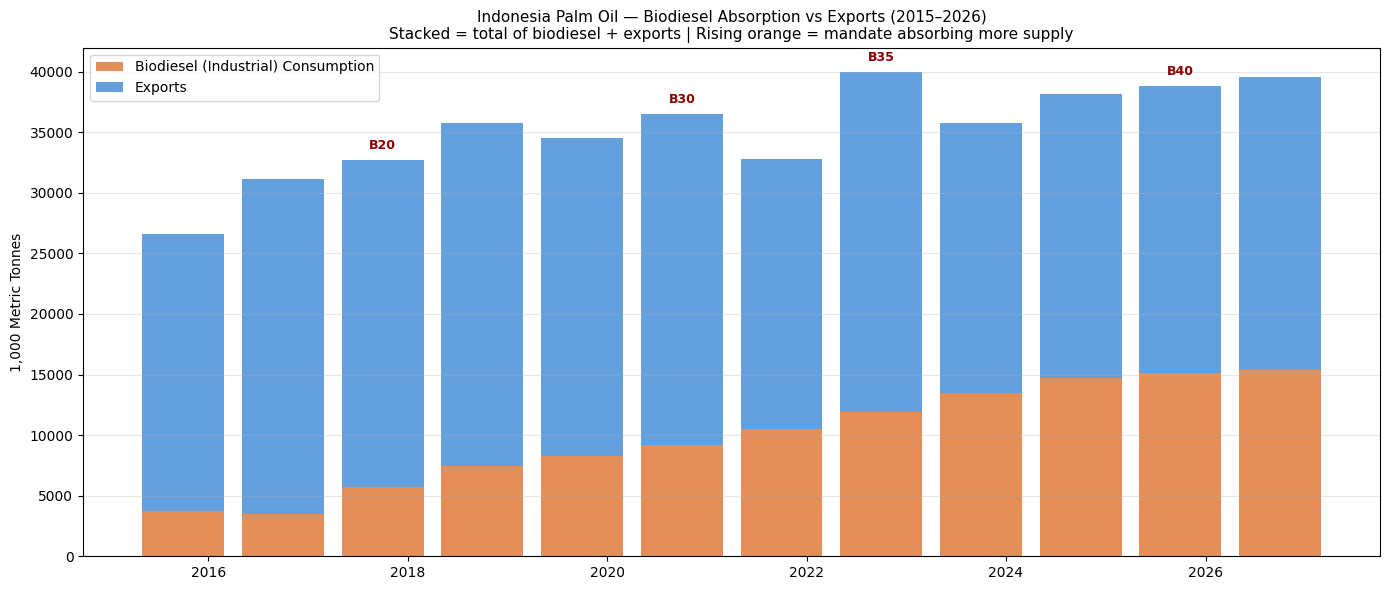

Chart 1 saved


In [ ]:
# This is the core Panel 1 chart for the dashboard.
# Orange = biodiesel absorption (growing every year with each mandate step)
# Blue  = exports (broadly flat despite rising production)
# The growing orange section is the visual story of Indonesia's B-mandate impact.
 
# One row per marketing year for clean annual bars
df_annual = df_monthly.drop_duplicates(subset=["production_1000mt"]).copy()
 
# Mandate milestone labels for annotation
mandates = {
    "2017-10-01": "B20",
    "2020-10-01": "B30",
    "2022-10-01": "B35",
    "2025-10-01": "B40"
}
 
fig, ax = plt.subplots(figsize=(14, 6))
 
ax.bar(df_annual["month_date"],
       df_annual["industrial_consumption_1000mt"],
       width=300, color="#e07b39", alpha=0.85,
       label="Biodiesel (Industrial) Consumption")
 
ax.bar(df_annual["month_date"],
       df_annual["exports_1000mt"],
       width=300, color="#4a90d9", alpha=0.85,
       bottom=df_annual["industrial_consumption_1000mt"],
       label="Exports")
 
# Annotate mandate milestones
for date_str, label in mandates.items():
    date = pd.Timestamp(date_str)
    if date in df_annual["month_date"].values:
        row = df_annual[df_annual["month_date"] == date].iloc[0]
        ax.annotate(    # places a text label at a specific location on the chart
            label,
            xy=(date,   # x position = date of mandate step
                row["industrial_consumption_1000mt"] + 
                row["exports_1000mt"]),
            xytext=(0, 8), textcoords="offset points",  # offset label slightly above the bar
            ha="center", fontsize=9, color="darkred", fontweight="bold"
        )
 
ax.set_ylabel("1,000 Metric Tonnes")
ax.set_title(
    "Indonesia Palm Oil — Biodiesel Absorption vs Exports (2015–2026)\n"
    "Stacked = total of biodiesel + exports | "
    "Rising orange = mandate absorbing more supply",
    fontsize=11
)
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3, axis="y")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.savefig("nb04_chart1_indonesia_supply.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 1 saved")

10. Chart 2: Biodiesel share of production trend

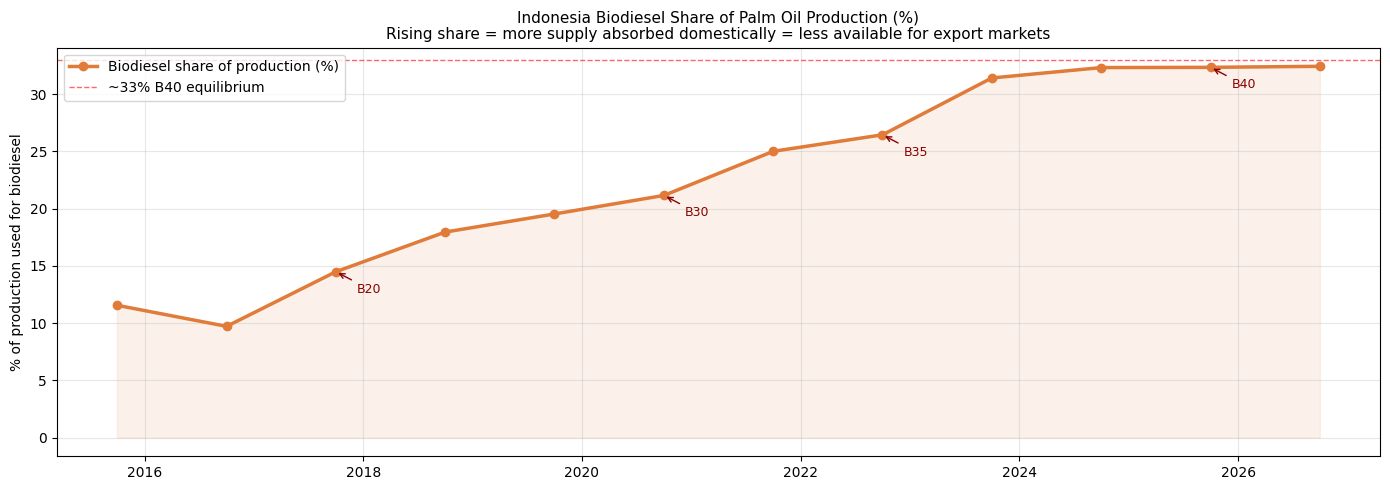

Chart 2 saved


In [32]:
# Single line showing what fraction of Indonesia's output goes into biodiesel.
# Each mandate step is annotated. The 33% reference line shows approximate
# B40 equilibrium — if the line approaches this, B50 becomes the next signal.
 
fig, ax = plt.subplots(figsize=(14, 5))
 
ax.plot(df_annual["month_date"],
        df_annual["biodiesel_share_pct"],
        color="#e07b39", linewidth=2.5,
        marker="o", markersize=6,
        label="Biodiesel share of production (%)")
 
ax.fill_between(df_annual["month_date"],
                df_annual["biodiesel_share_pct"],
                alpha=0.1, color="#e07b39")
 
ax.axhline(y=33, color="red", linestyle="--",
           linewidth=1, alpha=0.6, label="~33% B40 equilibrium")
 
for date_str, label in mandates.items():
    date = pd.Timestamp(date_str)
    if date in df_annual["month_date"].values:
        pct = df_annual.loc[
            df_annual["month_date"] == date, "biodiesel_share_pct"
        ].values[0]
        ax.annotate(
            label,
            xy=(date, pct),
            xytext=(15, -15), textcoords="offset points",
            arrowprops=dict(arrowstyle="->", color="darkred"),
            fontsize=9, color="darkred"
        )
 
ax.set_title(
    "Indonesia Biodiesel Share of Palm Oil Production (%)\n"
    "Rising share = more supply absorbed domestically = "
    "less available for export markets",
    fontsize=11
)
ax.set_ylabel("% of production used for biodiesel")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.savefig("nb04_chart2_biodiesel_share.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 2 saved")

11. Save output CSV

In [ ]:
output_cols = [
    "month_date",
    "production_1000mt",
    "industrial_consumption_1000mt",
    "exports_1000mt",
    "ending_stocks_1000mt",
    "biodiesel_share_pct"
]
 
df_monthly[output_cols].to_csv("nb04_usda_indonesia_monthly.csv", index=False)
print("Saved: nb04_usda_indonesia_monthly.csv")
print(f"Shape: {df_monthly[output_cols].shape}")
print(f"Columns: {output_cols}")

Saved nb04_usda_indonesia_monthly.csv
Shape: (133, 6)
Columns: ['month_date', 'ending_stocks_1000mt', 'exports_1000mt', 'industrial_consumption_1000mt', 'production_1000mt', 'biodiesel_share_pct']


12. Findings

**Source:** USDA FAS PSD bulk CSV download (no API key required)
**URL:** https://apps.fas.usda.gov/psdonline/downloads/psd_oilseeds_csv.zip
**File inside zip:** psd_oilseeds.csv
**Raw shape:** 801,669 rows × 12 columns (all oilseeds, all countries)
**Filtered shape:** 12 marketing years × 4 attributes (Indonesia palm oil only)
**After forward-fill to monthly:** 133 rows × 5 columns
**Date range:** 2015-10-01 → 2026-10-01
**Null values:** None

---

### Note on USDA API
The OpenData API (`apps.fas.usda.gov/OpenData`) returned 500 errors on all
endpoints including the simplest reference endpoints `/countries` and
`/commodities`. The api.data.gov API key returned 403 Bad API Key on all
attempts. The bulk CSV download is the correct alternative — same data, no
authentication required, updated monthly alongside WASDE report releases.
Use the bulk download in the production pipeline, not the API.

---

### Commodity and Country Confirmed
| Field | Code | Description |
|---|---|---|
| Commodity | 4243000 | Oil, Palm (not Palm Kernel — PKO serves cosmetics market) |
| Country | ID | Indonesia |
| Marketing year | Oct–Sep | USDA standard convention for palm oil |

---

### Attributes Selected and Why

| Attribute | ID | Unit | Why selected |
|---|---|---|---|
| production_1000mt | 28 | 1000 MT | Total supply starting point |
| industrial_consumption_1000mt | 140 | 1000 MT | Biodiesel absorption — the B-mandate number |
| exports_1000mt | 88 | 1000 MT | Volume reaching global market, competing with Malaysia |
| ending_stocks_1000mt | 176 | 1000 MT | Surplus or deficit signal |
| biodiesel_share_pct | derived | % | industrial_consumption / production × 100 |

**Why attribute 140 (Industrial Dom. Cons.) = biodiesel:**
In USDA's classification, industrial domestic consumption for palm oil
specifically means palm oil used for biodiesel and oleochemicals. For
Indonesia, the dominant industrial use is biodiesel by a large margin.
This is the number that jumps with every mandate increase from B20 → B30
→ B35 → B40.

---

### Why Forward-Fill Is Analytically Valid
Indonesia's B40 mandate allocates a fixed volume for the entire year —
there is no monthly breakdown of that allocation in any public source.
Forward-filling states that the same annual policy context applied
throughout each marketing year, which is correct. We are not fabricating
monthly precision — we are representing an annual policy decision on a
monthly time axis so it can join with World Bank and yfinance data in
Notebook 07.

---

### Key Findings

**Biodiesel mandate progression (biodiesel_share_pct):**

| Marketing Year | Biodiesel Share | Mandate Level |
|---|---|---|
| 2015 | 11.56% | B15/B20 beginning |
| 2018 | 17.95% | B20 nationwide rollout complete |
| 2020 | 21.15% | B30 implemented |
| 2022 | 26.44% | B35 implemented |
| 2025 | 32.33% | B40 implemented January 2025 |
| 2026 | 32.42% | B40 continuing, B50 road test underway |

One third of Indonesia's entire palm oil production now goes into domestic
biodiesel. This structural permanent demand sink did not exist in 2015. It
is the single most important supply-side change in global palm oil since
2015 and the primary reason CPO prices have stayed structurally elevated.

**Export trend — important nuance:**
Despite biodiesel absorbing an ever-larger share, exports have stayed
broadly flat at 22,000–28,000 MMT because production grew in parallel.
Indonesia is not starving the export market — they are growing production
fast enough to feed both the mandate and exports simultaneously. The real
risk to Malaysia is not Indonesia hoarding supply — it is Indonesia
producing so much that even after absorbing 32% domestically, they still
export approximately 24,000 MMT per year — roughly 3× Malaysia's export
volume.

**2021 and 2023 export dips — a repeating pattern:**
Both years show exports falling to ~22,000 MMT alongside mandate step-ups.
- 2021: B30 tightened domestic absorption → exports dipped
- 2023: B35 tightened further → exports dipped again

Both times exports recovered the following year as production caught up.
The pattern is consistent: mandate increases cause a 1-year export dip,
then production catches up and exports recover. Watch for this same
pattern when B50 is implemented (projected 2026/27).

**B50 forward signal:**
If B50 is implemented, industrial consumption would rise to approximately
19,000 MMT (~40% of production). Combined with flat production growth,
this would push exports below 22,000 MMT — the lowest in 15 years. CPO
prices would spike. Malaysia and SD Guthrie benefit directly from this
scenario.

---

### Columns for Pipeline

| Column | Type | Description |
|---|---|---|
| month_date | datetime (first of month) | Time axis |
| production_1000mt | float | Annual, forward-filled |
| industrial_consumption_1000mt | float | Annual, forward-filled (biodiesel) |
| exports_1000mt | float | Annual, forward-filled |
| ending_stocks_1000mt | float | Annual, forward-filled |
| biodiesel_share_pct | float | Derived, forward-filled |

---

**Next:** Notebook 05 — FAO FFPI Oils sub-index (keep or drop decision)